#### Chihuahua o muffin (CNN)

DenseNet121, modelo pre-entrenado de procesamiento de clasificacion usando redes convulucionadas, para el ejemplo "chihuahua o muffin" ([link](https://www.kaggle.com/datasets/samuelcortinhas/muffin-vs-chihuahua-image-classification?select=train)).

In [2]:
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import DenseNet121
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping
import matplotlib.pyplot as plt
import os
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns


In [3]:
train_dir = '../data/CNN/train'
test_dir = '../data/CNN/test'

# Parámetros
IMG_SIZE = (224, 224)
BATCH_SIZE = 32
EPOCHS = 10

# Generadores de datos
train_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2,
    horizontal_flip=True,
    zoom_range=0.2
)

train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary',
    subset='training'
)

validation_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary',
    subset='validation'
)

Found 2038 images belonging to 2 classes.
Found 508 images belonging to 2 classes.


In [4]:
# Cargar el modelo
base_model = DenseNet121(weights=None, include_top=False, input_shape=(224, 224, 3))

#Capas de clasificación
x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(1024, activation='relu')(x)
predictions = Dense(1, activation='sigmoid')(x)
model = Model(inputs=base_model.input, outputs=predictions)

# Congelar las capas base del modelo pre-entrenado
for layer in base_model.layers:
    layer.trainable = False

# Compilar el modelo
model.compile(optimizer=Adam(learning_rate=0.001), loss='binary_crossentropy', metrics=['accuracy'])

# Entrenamiento
early_stopping = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)
history = model.fit(
    train_generator,
    validation_data=validation_generator,
    epochs=EPOCHS,
    callbacks=[early_stopping]
)


Epoch 1/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 99s 1s/step - accuracy: 0.5206 - loss: 0.6963 - val_accuracy: 0.5453 - val_loss: 0.6868
Epoch 2/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 87s 1s/step - accuracy: 0.5447 - loss: 0.6894 - val_accuracy: 0.5453 - val_loss: 0.6812
Epoch 3/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 75s 1s/step - accuracy: 0.5662 - loss: 0.6848 - val_accuracy: 0.5453 - val_loss: 0.6797
Epoch 4/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 72s 1s/step - accuracy: 0.5589 - loss: 0.6859 - val_accuracy: 0.5453 - val_loss: 0.6694
Epoch 5/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 72s 1s/step - accuracy: 0.5888 - loss: 0.6745 - val_accuracy: 0.6476 - val_loss: 0.6559
Epoch 6/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 72s 1s/step - accuracy: 0.6246 - loss: 0.6607 - val_accuracy: 0.6575 - val_loss: 0.6315
Epoch 7/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 73s 1s/step - accuracy: 0.6379 - loss: 0.6482 - val_accuracy: 0.6673 - val_loss: 0.6093
Epoch 8/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 72s 1s/step - accuracy: 0.6879 - loss: 0.6278 - val_accuracy: 0.7461 - val_loss:

Found 722 images belonging to 2 classes.
23/23 ━━━━━━━━━━━━━━━━━━━━ 24s 893ms/step
              precision    recall  f1-score   support

      Muffin       0.81      0.77      0.79       418
   Chihuahua       0.70      0.75      0.73       304

    accuracy                           0.76       722
   macro avg       0.76      0.76      0.76       722
weighted avg       0.76      0.76      0.76       722



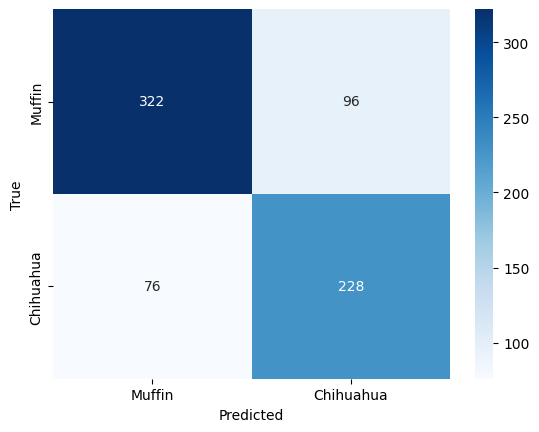

In [5]:
# Evaluar el modelo
test_datagen = ImageDataGenerator(rescale=1./255)
test_generator = test_datagen.flow_from_directory(
    test_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary',
    shuffle=False
)

#Predicciones
y_pred = model.predict(test_generator)
y_pred = np.round(y_pred).astype(int).reshape(-1)

#Labels reales 
y_true = test_generator.classes

#clasificación
print(classification_report(y_true, y_pred, target_names=['Muffin', 'Chihuahua']))

#Confusion matrix
cm = confusion_matrix(y_true, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Muffin', 'Chihuahua'], yticklabels=['Muffin', 'Chihuahua'])
plt.xlabel('Predicted')
plt.ylabel('True')
plt.show()


Show me the mistakes

23/23 ━━━━━━━━━━━━━━━━━━━━ 21s 890ms/step


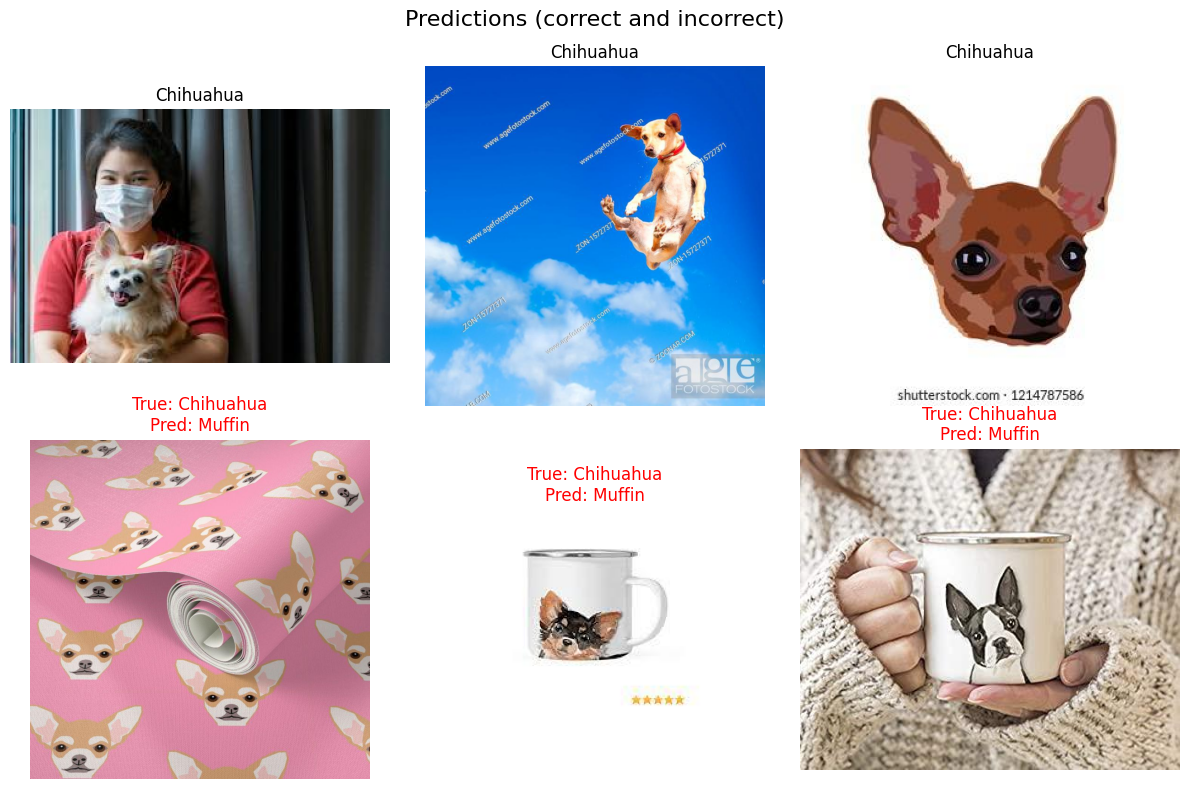

In [ ]:
# Get predictions with probabilities
y_pred_proba = model.predict(test_generator)
y_pred_class = np.round(y_pred).astype(int).reshape(-1)

# Get file paths
test_files = test_generator.filenames
y_true = test_generator.classes

# Identify correct and incorrect predictions
correct_mask = y_pred_class == y_true
incorrect_mask = y_pred_class != y_true

correct_indices = np.where(correct_mask)[0]
incorrect_indices = np.where(incorrect_mask)[0]

# Plot correct predictions
fig, axes = plt.subplots(2, 3, figsize=(12, 8))
fig.suptitle('Predictions (correct and incorrect)', fontsize=16)
for idx, ax in enumerate(axes[0]):
    if idx < len(correct_indices):
        img_path = os.path.join(test_dir, test_files[correct_indices[idx]])
        img = plt.imread(img_path)
        label = 'Chihuahua' if y_true[correct_indices[idx]] == 0 else 'Muffin'
        ax.imshow(img)
        ax.set_title(f'{label}')
        ax.axis('off')

# Plot incorrect predictions
for idx, ax in enumerate(axes[1]):
    if idx < len(incorrect_indices):
        img_path = os.path.join(test_dir, test_files[incorrect_indices[idx]])
        img = plt.imread(img_path)
        true_label = 'Chihuahua' if y_true[incorrect_indices[idx]] == 0 else 'Muffin'
        pred_label = 'Chihuahua' if y_pred_class[incorrect_indices[idx]] == 0 else 'Muffin'
        ax.imshow(img)
        ax.set_title(f'True: {true_label}\nPred: {pred_label}', color='red')
        ax.axis('off')

plt.tight_layout()
plt.show()

In [13]:
# Cargar el modelo
base_model = DenseNet121(weights='imagenet', include_top=False, input_shape=(224, 224, 3))

#Capas de clasificación
x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(1024, activation='relu')(x)
predictions = Dense(1, activation='sigmoid')(x)
model2 = Model(inputs=base_model.input, outputs=predictions)

# Congelar las capas base del modelo pre-entrenado
for layer in base_model.layers:
    layer.trainable = False

# Compilar el modelo
model2.compile(optimizer=Adam(learning_rate=0.001), loss='binary_crossentropy', metrics=['accuracy'])

# Entrenamiento
early_stopping = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)
history = model2.fit(
    train_generator,
    validation_data=validation_generator,
    epochs=EPOCHS,
    callbacks=[early_stopping]
)


Epoch 1/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 108s 1s/step - accuracy: 0.9740 - loss: 0.0596 - val_accuracy: 0.9843 - val_loss: 0.0530
Epoch 2/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 89s 1s/step - accuracy: 0.9971 - loss: 0.0112 - val_accuracy: 0.9843 - val_loss: 0.0698
Epoch 3/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 83s 1s/step - accuracy: 0.9961 - loss: 0.0138 - val_accuracy: 0.9921 - val_loss: 0.0316
Epoch 4/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 79s 1s/step - accuracy: 0.9966 - loss: 0.0099 - val_accuracy: 0.9902 - val_loss: 0.0802
Epoch 5/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 84s 1s/step - accuracy: 0.9961 - loss: 0.0106 - val_accuracy: 0.9705 - val_loss: 0.1654
Epoch 6/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 84s 1s/step - accuracy: 0.9980 - loss: 0.0082 - val_accuracy: 0.9606 - val_loss: 0.1650


Found 722 images belonging to 2 classes.
23/23 ━━━━━━━━━━━━━━━━━━━━ 29s 1s/step 
              precision    recall  f1-score   support

      Muffin       1.00      0.99      0.99       418
   Chihuahua       0.98      0.99      0.99       304

    accuracy                           0.99       722
   macro avg       0.99      0.99      0.99       722
weighted avg       0.99      0.99      0.99       722



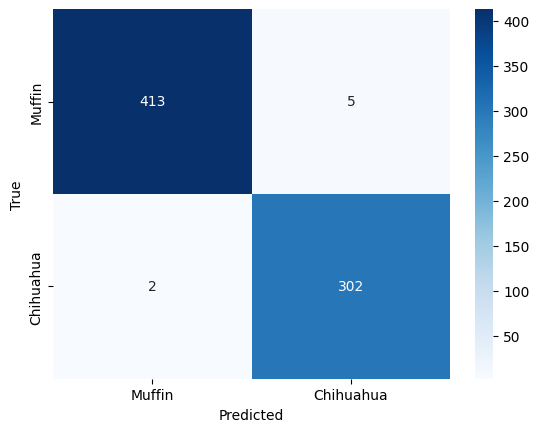

In [14]:
# Evaluar el modelo
test_datagen = ImageDataGenerator(rescale=1./255)
test_generator = test_datagen.flow_from_directory(
    test_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary',
    shuffle=False
)

#Predicciones
y_pred2 = model2.predict(test_generator)
y_pred2 = np.round(y_pred2).astype(int).reshape(-1)

#Labels reales 
y_true = test_generator.classes

#clasificación
print(classification_report(y_true, y_pred2, target_names=['Muffin', 'Chihuahua']))

#Confusion matrix
cm = confusion_matrix(y_true, y_pred2)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Muffin', 'Chihuahua'], yticklabels=['Muffin', 'Chihuahua'])
plt.xlabel('Predicted')
plt.ylabel('True')
plt.show()


23/23 ━━━━━━━━━━━━━━━━━━━━ 21s 925ms/step


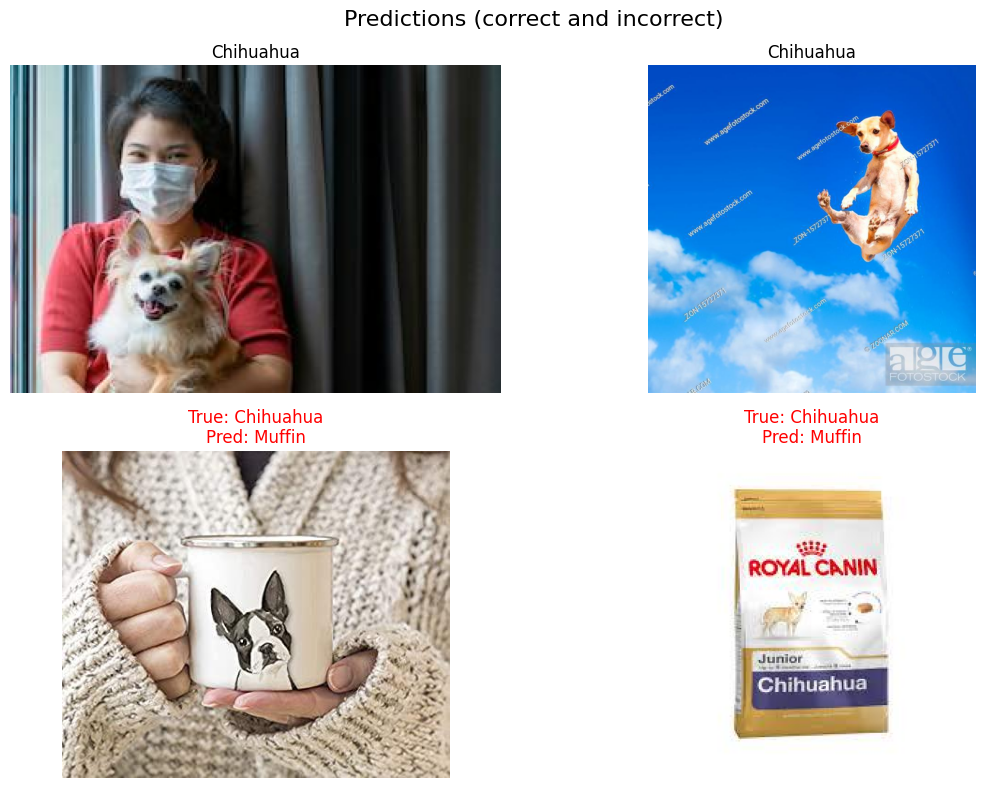

In [16]:
# Get predictions with probabilities
y_pred_proba2 = model2.predict(test_generator)
y_pred_class2 = np.round(y_pred2).astype(int).reshape(-1)

# Get file paths
test_files = test_generator.filenames
y_true = test_generator.classes

# Identify correct and incorrect predictions
correct_mask = y_pred_class2 == y_true
incorrect_mask = y_pred_class2 != y_true

correct_indices = np.where(correct_mask)[0]
incorrect_indices = np.where(incorrect_mask)[0]

# Plot correct predictions
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
fig.suptitle('Predictions (correct and incorrect)', fontsize=16)
for idx, ax in enumerate(axes[0]):
    if idx < len(correct_indices):
        img_path = os.path.join(test_dir, test_files[correct_indices[idx]])
        img = plt.imread(img_path)
        label = 'Chihuahua' if y_true[correct_indices[idx]] == 0 else 'Muffin'
        ax.imshow(img)
        ax.set_title(f'{label}')
        ax.axis('off')

# Plot incorrect predictions
for idx, ax in enumerate(axes[1]):
    if idx < len(incorrect_indices):
        img_path = os.path.join(test_dir, test_files[incorrect_indices[idx]])
        img = plt.imread(img_path)
        true_label = 'Chihuahua' if y_true[incorrect_indices[idx]] == 0 else 'Muffin'
        pred_label = 'Chihuahua' if y_pred_class[incorrect_indices[idx]] == 0 else 'Muffin'
        ax.imshow(img)
        ax.set_title(f'True: {true_label}\nPred: {pred_label}', color='red')
        ax.axis('off')

plt.tight_layout()
plt.show()